In [1]:
# statistical tests using the data 
#   load the correponding dataset by un-commenting the corresponding line
#   normality tests 

######  For two groups only, no covariates  ######
####  Perform t-test/Wilcoxon rank-sum analysis for Gaissian/Non-Gaussian distributions  ###

########   For multiple groups   #########
####  Perform Anova analysis for Gaussian distributions  ###

########   Adding covariates, two or multiple groups  ########
###  Perform ANCOVA analysis  ###

########   Adding covariates  ########
###  Perform GLM analsis, using the formular vresion smf.glm  ###
###  For Non-Gaussian distributions, here the param is still default to Gaussian!   ###

###########   Adding covariates  ############
#####   Perform Rank-Based ANCOVA, for Non-Gaussian distributions   ###

####    Data Inspection and Plotting    ####

In [2]:
import numpy as np
import pandas as pd

from scipy.stats import shapiro   # for normality test

from scipy.stats import f_oneway  # for Anova test (normal distribution)
from scipy.stats import kruskal   # for Kruskal-Wallis test (non-normal distribution)

import statsmodels.api as sm      # for Ancova, , non-formular form
import statsmodels.formula.api as smf # for ANCOVA test, formular form

from scipy.stats import rankdata  # for Rank-Based ANCOVA, for Non-Gaussian distributions

import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
curRoot = 'C'  # 'C' or 'D'

In [4]:
# Load shape measures, SELECTED
curRegion = 'CSSyl' # !!! modify !!! CSSyl, CSpreCS
curSCA = 1         # !!! modify !!!
typeDist = 'max'

##############################################   Original   #############################################
# for CSpreCS analysis
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\Combined_Select_CSV_first_time_point\{curRegion}_ctl_sca1_time1_{typeDist}.csv'
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\Combined_Select_CSV_first_time_point\{curRegion}_ctl_sca2_time1_{typeDist}.csv'
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\Combined_Select_CSV_first_time_point\{curRegion}_ctl_sca3_time1_{typeDist}.csv'
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\Combined_Select_CSV_first_time_point\{curRegion}_ctl_sca7_time1_{typeDist}.csv'

#file_path_ctl_1_max = rf'D:\B_projWIP\proj_ataxia\Combined_Select_CSV\{curRegion}_atrilBioscaCermoi_combined_select_ctl_sca1_max.csv'

# Time 1 and 2 separated, from combined set 
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\Combined_Select_CSV\{curRegion}_ctl_sca1_time1_{typeDist}.csv'
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\Combined_Select_CSV\{curRegion}_ctl_sca1_time2_{typeDist}.csv'

# Time 1 and 2 combined, from combined set 
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\Combined_Select_CSV\{curRegion}_ctl_sca1_time1_and_2_{typeDist}.csv'

#Original, time1 only
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\{curRegion}_atrilBioscaCermoi_combined_select_ctl_sca1_{typeDist}.csv'

#Original REDO for verification
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\ORI\ORI_time1_ctl_sca1\{curRegion}\combined_time1_{typeDist}_ctl_sca1.csv'

# SCAs 2, 3, 7
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\{curRegion}_atrilBioscaCermoi_combined_select_ctl_sca2_{typeDist}.csv'
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\{curRegion}_atrilBioscaCermoi_combined_select_ctl_sca3_{typeDist}.csv'
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\{curRegion}_atrilBioscaCermoi_combined_select_ctl_sca7_{typeDist}.csv'

###########################################    RELABEL     #############################################
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\RELABEL\relabel_time1_ctl_sca{curSCA}\{curRegion}\combined_time1_{typeDist}_ctl_sca{curSCA}.csv'

###########################################   RELABEL, REDO    #############################################
curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\RELABEL_REDO\RELABEL_REDO_time1_2_ctl_sca{curSCA}\{curRegion}\combined_time1_2_{typeDist}_ctl_sca{curSCA}.csv'
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\RELABEL_REDO\RELABEL_REDO_time1_ctl_sca{curSCA}\{curRegion}\combined_time1_{typeDist}_ctl_sca{curSCA}.csv'
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\RELABEL_REDO\RELABEL_REDO_time2_ctl_sca{curSCA}\{curRegion}\combined_time2_{typeDist}_ctl_sca{curSCA}.csv'


print(curPath)
combined = pd.read_csv(curPath)
print(len(combined))

### !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!  ###
####################################  only for time1 and 2 together  ####################################
#combined_time1 = combined[combined['Time_point']==1]
#combined_time2 = combined[combined['Time_point']!=1] # BIOSCA==2, CERMOI==3
#combined = combined_time2         ###########################    CHANGE    #############################
### !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!  ###

combined.index = combined['subjName']

# for specific analysis, remove NAs
combined_L = combined[combined.index.str.startswith('L')]
combined_R = combined[combined.index.str.startswith('flip')]
combined_only_SCA = combined[combined['SCA'] == curSCA]

combined_CAG = combined.dropna(subset=['CAG'])
combined_CAG_only_SCA = combined_CAG[combined_CAG['SCA'] == curSCA]

combined_CCFS = combined.dropna(subset=['CCFS'])
combined_CCFS_only_SCA = combined_CCFS[combined_CCFS['SCA'] == curSCA]

combined_INAS = combined.dropna(subset=['INAS'])
combined_INAS_only_SCA = combined_INAS[combined_INAS['SCA'] == curSCA]

C:\B_projWIP\proj_ataxia\RELABEL_REDO\RELABEL_REDO_time1_2_ctl_sca1\CSSyl\combined_time1_2_max_ctl_sca1.csv
166


In [5]:
combined.columns

Index(['subjName', 'label', 'surface_talairach', 'surface_native',
       'maxdepth_talairach', 'maxdepth_native', 'meandepth_talairach',
       'meandepth_native', 'hull_junction_length_talairach',
       'hull_junction_length_native', 'GM_thickness', 'opening',
       'Randomization', 'SCA', 'CAG', 'Sex', 'Age', 'SARA', 'INAS',
       'Time_point', 'CodeICM', 'iso1', 'iso2', 'iso3', 'UMAP1_U1', 'UMAP1_U2',
       'UMAP1_U3', 'UMAP2_U3', 'UMAP1_U4', 'UMAP2_U4', 'Age_onset',
       'Group_ctl_pre_pat', 'Handedness', 'CCFS', 'Disease_duration',
       'allele1', 'allele2', 'side', 'SCA_side', 'dominantSide',
       'SCA_dominantSide', 'iso1_asy', 'iso2_asy', 'iso3_asy', 'UMAP1_U1_asy',
       'UMAP1_U2_asy', 'UMAP1_U3_asy', 'UMAP2_U3_asy', 'UMAP1_U4_asy',
       'UMAP2_U4_asy', 'surface_talairach_asy', 'surface_native_asy',
       'maxdepth_talairach_asy', 'maxdepth_native_asy',
       'meandepth_talairach_asy', 'meandepth_native_asy',
       'hull_junction_length_talairach_asy', 'hull_

In [6]:
print(len(combined_CAG))
print(len(combined_only_SCA))
print(len(combined_CAG_only_SCA))
print(combined_CAG.columns)

84
62
62
Index(['subjName', 'label', 'surface_talairach', 'surface_native',
       'maxdepth_talairach', 'maxdepth_native', 'meandepth_talairach',
       'meandepth_native', 'hull_junction_length_talairach',
       'hull_junction_length_native', 'GM_thickness', 'opening',
       'Randomization', 'SCA', 'CAG', 'Sex', 'Age', 'SARA', 'INAS',
       'Time_point', 'CodeICM', 'iso1', 'iso2', 'iso3', 'UMAP1_U1', 'UMAP1_U2',
       'UMAP1_U3', 'UMAP2_U3', 'UMAP1_U4', 'UMAP2_U4', 'Age_onset',
       'Group_ctl_pre_pat', 'Handedness', 'CCFS', 'Disease_duration',
       'allele1', 'allele2', 'side', 'SCA_side', 'dominantSide',
       'SCA_dominantSide', 'iso1_asy', 'iso2_asy', 'iso3_asy', 'UMAP1_U1_asy',
       'UMAP1_U2_asy', 'UMAP1_U3_asy', 'UMAP2_U3_asy', 'UMAP1_U4_asy',
       'UMAP2_U4_asy', 'surface_talairach_asy', 'surface_native_asy',
       'maxdepth_talairach_asy', 'maxdepth_native_asy',
       'meandepth_talairach_asy', 'meandepth_native_asy',
       'hull_junction_length_talairach_asy

In [7]:
########################################  Stats  #############################################

In [8]:
#########################  Testing Normality  ##########################

measures = [
    'iso1', 'iso2', 'iso3', 'UMAP1_U1', 'UMAP1_U2', 'UMAP1_U3', 'UMAP2_U3', 'UMAP1_U4', 'UMAP2_U4',
    'opening','maxdepth_talairach','iso1_asy','iso2_asy','iso3_asy','UMAP1_U1_asy','UMAP1_U2_asy','UMAP1_U3_asy','UMAP1_U4_asy','UMAP2_U4_asy'
]

# Shapiro-Wilk test for normality, not normally distributed if p-val < 0.05
def run_shapiro_tests(df, measure_list):
    for measure in measure_list:
        if measure in df.columns:
            stat, p_value = shapiro(df[measure].dropna())  # dropna to avoid issues with NaN
            print(f'{measure} p-val: {p_value}')
        else:
            print(f"Warning: '{measure}' not found in DataFrame columns.")

# Run the function
print('Normality test stats for Control + SCA:')
run_shapiro_tests(combined, measures)
print()
print('Normality test stats for only SCA:')
run_shapiro_tests(combined_only_SCA, measures)

Normality test stats for Control + SCA:
iso1 p-val: 0.29079951384854036
iso2 p-val: 0.020540159062166847
iso3 p-val: 0.016863749717678175
UMAP1_U1 p-val: 0.0008037296414664206
UMAP1_U2 p-val: 0.0007196906290342857
UMAP1_U3 p-val: 3.1439647313704286e-07
UMAP2_U3 p-val: 2.2177122051707535e-06
UMAP1_U4 p-val: 0.008033057728214337
UMAP2_U4 p-val: 0.009545472449182626
opening p-val: 0.029856162779388674
maxdepth_talairach p-val: 0.04531277022439186
iso1_asy p-val: 6.071528660836501e-25
iso2_asy p-val: 3.784070338729271e-21
iso3_asy p-val: 4.9741066718219593e-26
UMAP1_U1_asy p-val: 2.489652068837133e-25
UMAP1_U2_asy p-val: 2.5766908001240443e-25
UMAP1_U3_asy p-val: 2.5552287290456586e-09
UMAP1_U4_asy p-val: 0.0009285694067584727
UMAP2_U4_asy p-val: 0.00014684939654429493

Normality test stats for only SCA:
iso1 p-val: 0.050723608882434934
iso2 p-val: 0.06285792455826053
iso3 p-val: 0.5570674177202833
UMAP1_U1 p-val: 0.03040037041677266
UMAP1_U2 p-val: 0.0015377191182252457
UMAP1_U3 p-val: 0.

In [20]:
#########################  Testing Normality, by hemisphere  ##########################

measures = [
    'iso1', 'iso2', 'iso3', 'UMAP1_U1', 'UMAP1_U2', 'UMAP1_U3', 'UMAP2_U3', 'UMAP1_U4', 'UMAP2_U4',
    'opening', 'maxdepth_talairach', 'iso1_asy','iso2_asy', 'UMAP1_U3_asy', 'UMAP2_U3_asy', 'UMAP1_U4_asy', 'UMAP2_U4_asy'
]

# Shapiro-Wilk test for normality, not normally distributed if p-val < 0.05
def run_shapiro_tests(df, measure_list):
    for measure in measure_list:
        if measure in df.columns:
            stat, p_value = shapiro(df[measure].dropna())  # dropna to avoid issues with NaN
            print(f'{measure} p-val: {p_value}')
        else:
            print(f"Warning: '{measure}' not found in DataFrame columns.")

# Run the function
print('Normality test stats for combined_L:')
run_shapiro_tests(combined_L, measures)
print()
print('Normality test stats for combined_R:')
run_shapiro_tests(combined_R, measures)

#############  Enable scrolling for the output  #############
from IPython.core.display import display, HTML
display(HTML("<style>.output_scroll {height: 300px; overflow-y: scroll;}</style>")) #right click on output to enable scrolling

Normality test stats for combined_L:
iso1 p-val: 0.006415077818189712
iso2 p-val: 0.0008514807429588979
iso3 p-val: 0.06613509184657165
UMAP1_U1 p-val: 0.07594136775773955
UMAP1_U2 p-val: 0.026780680149258825
UMAP1_U3 p-val: 1.584869543503707e-05
UMAP2_U3 p-val: 0.00020282825570081735
UMAP1_U4 p-val: 0.011370520426123779
UMAP2_U4 p-val: 0.050051447970566196
opening p-val: 0.1644961926205798
maxdepth_talairach p-val: 0.4854503130852998
iso1_asy p-val: 4.8853032416896355e-18
iso2_asy p-val: 5.5574400136333314e-15
UMAP1_U3_asy p-val: 8.375324428670225e-06
UMAP2_U3_asy p-val: 7.115955933894632e-12
UMAP1_U4_asy p-val: 0.05567729772661902
UMAP2_U4_asy p-val: 0.0166876351531323

Normality test stats for combined_R:
iso1 p-val: 0.12693062219631468
iso2 p-val: 0.05882913176043714
iso3 p-val: 0.17984848424113237
UMAP1_U1 p-val: 0.0019123699139267174
UMAP1_U2 p-val: 0.008638291471133075
UMAP1_U3 p-val: 0.00048427498592638717
UMAP2_U3 p-val: 7.180835815719158e-05
UMAP1_U4 p-val: 0.0106435746317783

C:\Users\joyca\AppData\Local\Temp\ipykernel_35828\3551839074.py:25: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import display, HTML


In [22]:
########  Perform ANCOVA and GLM analysis, Gaussian distribution  ########
########  Perform ranked ANCOVA, non-Gaussian distribution  ########
########   Adding covariates, two or multiple groups   ########

def ancovaGLMTests(df,measures,x_var):   # df, measures are the dependant variables, x_var is the independant variables
    df.loc[:, 'SCA'] = df['SCA'].astype('category')       # Ensure 'SCA' is a categorical variable    
    results_dict = {}                                     # Initialize a dictionary to store results
   
    ##covariates = 'Age + C(Sex) + C(side)'                
    ##covariates = 'Age + C(Sex) + C(side) + C(CodeICM)'  # if NOT from the same centre   
    #covariates = 'Age + C(Sex) + C(side) + Age_onset'              # if ONLY patients
    #covariatesRanked = ['Age','Sex','side','Age_onset']         # if ONLY patients
    covariates = 'Age + C(side) + Age_onset'              # if ONLY patients
    covariatesRanked = ['Age','side','Age_onset']         # if ONLY patients
    #covariates = 'Age + C(side)'              
    #covariatesRanked = ['Age','side']            
    
    for measure in measures:
        formula = rf'{measure} ~ {x_var} + {covariates}'   # Define the model formula dynamically       
        model = smf.ols(formula, data=df).fit()            # Fit the model        
        print(rf'ANCOVA results for ###################    {measure}    ###################:')
        print(model.summary())
        print("\n" + "="*80 + "\n")  # Divider between each measure's output
        anova_table = sm.stats.anova_lm(model, typ=2) 
        print(anova_table)
        
        ###################      Format p-value in scientific notation     ###################
        summary_table = pd.DataFrame({         
            'Coefficient': model.params,
            'Standard Error': model.bse,
            't-Value': model.tvalues,
            'P-Value': model.pvalues.apply(lambda x: f"{x:.2e}")  # Format p-values in scientific notation
        })        
        #print("Custom ANCOVA Results:")     # Display formatted results, ONLY if scientific notation needed
        #print(summary_table)

        ########################################     GLM     #######################################
        print("============================   GLM " + measure + "  ============================")
        glm_model = smf.glm(formula=formula, data=df).fit()
        print(f"GLM results for {measure}:\n")
        print(glm_model.summary())

        #######################    Ranked ANCOVA for non_Gaussian data    ########################
        covariatesRanked = [cov.strip() for cov in covariatesRanked if cov.strip()]

        df['Ranked_Outcome'] = rankdata(df[measure])    # Step 1: Rank the Outcome Variable       
        # Formula: Outcome ~ Group + Covariate  
        formula = rf"Ranked_Outcome ~ {x_var} + {' + '.join(covariatesRanked)}"    # Step 2: Perform ANCOVA on Ranked Data
        model = smf.ols(formula, data=df).fit()

        # Display the summary
        print("========================   Rank-Based ANCOVA: " + measure + "==========================" )
        print(model.summary())

measures_complete = [
    'iso1', 'iso2', 'iso3', 'UMAP1_U1', 'UMAP1_U2', 'UMAP1_U3', 'UMAP2_U3', 'UMAP1_U4', 'UMAP2_U4',
    'surface_talairach','surface_native','maxdepth_talairach','maxdepth_native','meandepth_talairach',
    'meandepth_native','hull_junction_length_talairach','hull_junction_length_native','GM_thickness','opening',
    'iso1_asy','iso2_asy','iso3_asy','UMAP1_U1_asy','UMAP1_U2_asy','UMAP1_U3_asy','UMAP2_U3_asy','UMAP1_U4_asy','UMAP2_U4_asy',
    'surface_talairach_asy','surface_native_asy','maxdepth_talairach_asy','maxdepth_native_asy','meandepth_talairach_asy',
    'meandepth_native_asy','hull_junction_length_talairach_asy','hull_junction_length_native_asy','GM_thickness_asy','opening_asy'
]
curMeasures = [                                  # the dependant variables, 
    'iso1', 'iso2', 'iso3', 'UMAP1_U1', 'UMAP1_U2', 'UMAP1_U3', 'UMAP2_U3', 'UMAP1_U4', 'UMAP2_U4','iso1_asy','iso2_asy','iso3_asy'
]

#cur_x_vars = ['SCA']                         # the independant variables
cur_x_vars = ['SARA','CAG','CCFS','INAS'] 
#cur_x_vars = ['Age_onset']  
#cur_x_vars = ['CAG'] 


# Run the function
for x_var in cur_x_vars:
    print(rf'###################################        {x_var}        #####################################')     
    if x_var == 'SCA':
        ancovaGLMTests(combined, curMeasures, x_var)        
    if x_var == 'SARA':
        ancovaGLMTests(combined_only_SCA, curMeasures, x_var)
    if x_var == 'CAG':
        ancovaGLMTests(combined_CAG_only_SCA, curMeasures, x_var) 
    if x_var == 'CCFS':
        if len(combined_CCFS_only_SCA) > 0:
            ancovaGLMTests(combined_CCFS_only_SCA, curMeasures, x_var) 
        else:
            print('No CCFS info.')
    if x_var == 'INAS':
        if len(combined_INAS_only_SCA) > 0:
            ancovaGLMTests(combined_INAS_only_SCA, curMeasures, x_var) 
        else:
            print('No INAS info.')
    if x_var == 'Age_onset':
        ancovaGLMTests(combined_CAG_only_SCA, curMeasures, x_var)         


#############  Enable scrolling for the output  #############
from IPython.core.display import display, HTML
display(HTML("<style>.output_scroll {height: 300px; overflow-y: scroll;}</style>")) #right click on output to enable scrolling

###################################        SARA        #####################################
ANCOVA results for ###################    iso1    ###################:
                            OLS Regression Results                            
Dep. Variable:                   iso1   R-squared:                       0.203
Model:                            OLS   Adj. R-squared:                  0.142
Method:                 Least Squares   F-statistic:                     3.368
Date:                Mon, 17 Mar 2025   Prob (F-statistic):             0.0158
Time:                        14:09:25   Log-Likelihood:                -153.65
No. Observations:                  58   AIC:                             317.3
Df Residuals:                      53   BIC:                             327.6
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t 

C:\Users\joyca\AppData\Local\Temp\ipykernel_35828\616118355.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Ranked_Outcome'] = rankdata(df[measure])    # Step 1: Rank the Outcome Variable
C:\Users\joyca\AppData\Local\Temp\ipykernel_35828\616118355.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Ranked_Outcome'] = rankdata(df[measure])    # Step 1: Rank the Outcome Variable
C:\Users\joyca\AppData\Local\Temp\ipykernel_35828\616118355.py:46: SettingWithCopyWarning: 
A value is trying to be se

========================   Rank-Based ANCOVA: iso3==========================
                            OLS Regression Results                            
Dep. Variable:         Ranked_Outcome   R-squared:                       0.058
Model:                            OLS   Adj. R-squared:                 -0.013
Method:                 Least Squares   F-statistic:                    0.8213
Date:                Mon, 17 Mar 2025   Prob (F-statistic):              0.517
Time:                        14:09:25   Log-Likelihood:                -247.21
No. Observations:                  58   AIC:                             504.4
Df Residuals:                      53   BIC:                             514.7
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------

C:\Users\joyca\AppData\Local\Temp\ipykernel_35828\616118355.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Ranked_Outcome'] = rankdata(df[measure])    # Step 1: Rank the Outcome Variable
C:\Users\joyca\AppData\Local\Temp\ipykernel_35828\616118355.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Ranked_Outcome'] = rankdata(df[measure])    # Step 1: Rank the Outcome Variable
C:\Users\joyca\AppData\Local\Temp\ipykernel_35828\616118355.py:46: SettingWithCopyWarning: 
A value is trying to be se

               sum_sq    df         F    PR(>F)
C(side)      1.139680   1.0  0.115243  0.735594
SARA        47.832271   1.0  4.836724  0.032244
Age         22.687740   1.0  2.294149  0.135804
Age_onset   29.532235   1.0  2.986253  0.089797
Residual   524.137860  53.0       NaN       NaN
============================   GLM UMAP2_U3  ============================
GLM results for UMAP2_U3:

                 Generalized Linear Model Regression Results                  
Dep. Variable:               UMAP2_U3   No. Observations:                   58
Model:                            GLM   Df Residuals:                       53
Model Family:                Gaussian   Df Model:                            4
Link Function:               Identity   Scale:                          9.8894
Method:                          IRLS   Log-Likelihood:                -146.14
Date:                Mon, 17 Mar 2025   Deviance:                       524.14
Time:                        14:09:26   Pearson chi2:     

...

C:\Users\joyca\AppData\Local\Temp\ipykernel_35828\616118355.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Ranked_Outcome'] = rankdata(df[measure])    # Step 1: Rank the Outcome Variable
C:\Users\joyca\AppData\Local\Temp\ipykernel_35828\616118355.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Ranked_Outcome'] = rankdata(df[measure])    # Step 1: Rank the Outcome Variable
C:\Users\joyca\AppData\Local\Temp\ipykernel_35828\616118355.py:46: SettingWithCopyWarning: 
A value is trying to be se

                            OLS Regression Results                            
Dep. Variable:               UMAP1_U4   R-squared:                       0.214
Model:                            OLS   Adj. R-squared:                  0.155
Method:                 Least Squares   F-statistic:                     3.609
Date:                Mon, 17 Mar 2025   Prob (F-statistic):             0.0113
Time:                        14:09:28   Log-Likelihood:                -86.418
No. Observations:                  58   AIC:                             182.8
Df Residuals:                      53   BIC:                             193.1
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        4.2479      1.963      2.164   

C:\Users\joyca\AppData\Local\Temp\ipykernel_35828\616118355.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Ranked_Outcome'] = rankdata(df[measure])    # Step 1: Rank the Outcome Variable
C:\Users\joyca\AppData\Local\Temp\ipykernel_35828\616118355.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Ranked_Outcome'] = rankdata(df[measure])    # Step 1: Rank the Outcome Variable
C:\Users\joyca\AppData\Local\Temp\ipykernel_35828\616118355.py:46: SettingWithCopyWarning: 
A value is trying to be se

ANCOVA results for ###################    iso2_asy    ###################:
                            OLS Regression Results                            
Dep. Variable:               iso2_asy   R-squared:                       0.143
Model:                            OLS   Adj. R-squared:                  0.078
Method:                 Least Squares   F-statistic:                     2.208
Date:                Mon, 17 Mar 2025   Prob (F-statistic):             0.0805
Time:                        14:09:28   Log-Likelihood:                -234.80
No. Observations:                  58   AIC:                             479.6
Df Residuals:                      53   BIC:                             489.9
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------

C:\Users\joyca\AppData\Local\Temp\ipykernel_35828\616118355.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Ranked_Outcome'] = rankdata(df[measure])    # Step 1: Rank the Outcome Variable
C:\Users\joyca\AppData\Local\Temp\ipykernel_35828\616118355.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Ranked_Outcome'] = rankdata(df[measure])    # Step 1: Rank the Outcome Variable
C:\Users\joyca\AppData\Local\Temp\ipykernel_35828\616118355.py:97: DeprecationWarning: Importing display from IPython.

In [11]:
####    Data Inspection and Plotting    ####

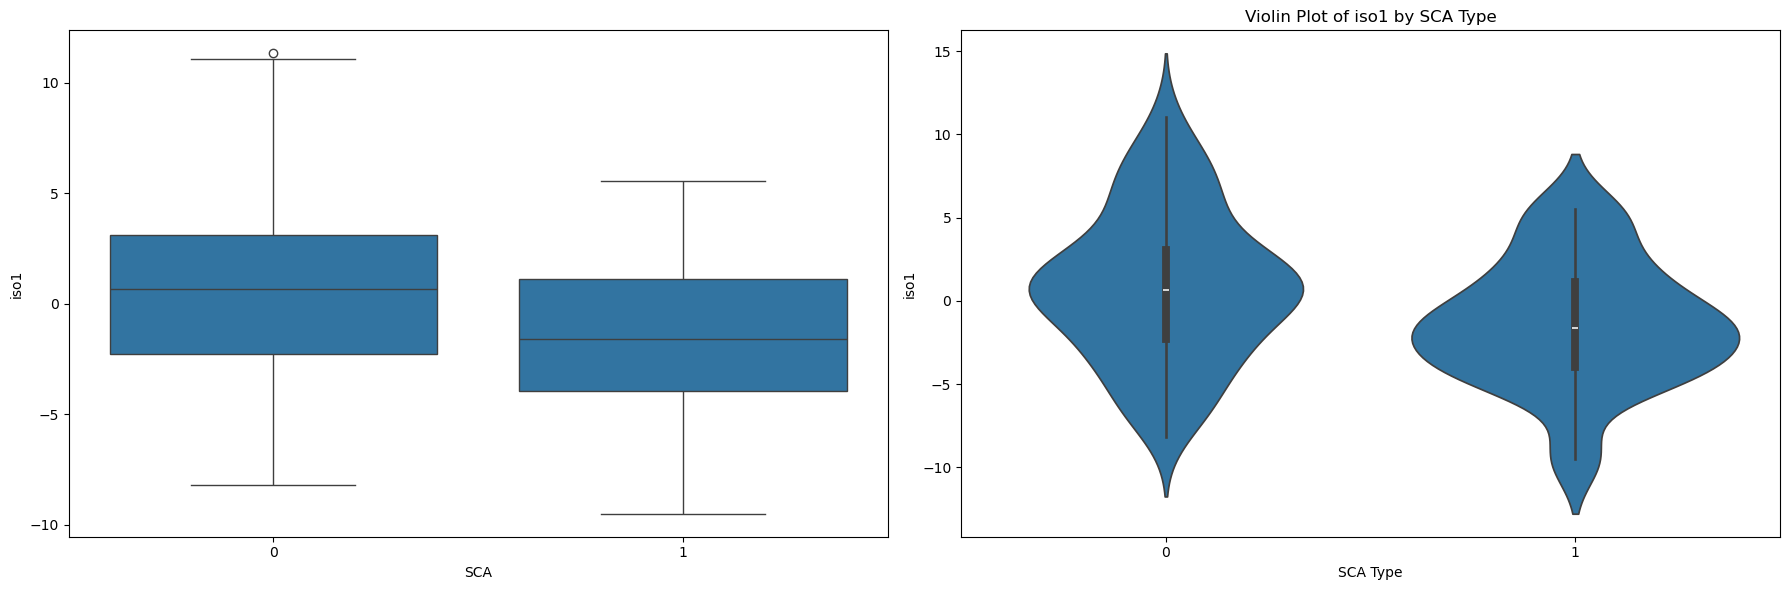

In [14]:
###########  simple boxplot  ###########

df = combined
curData = 'iso1'

fig, axs = plt.subplots(1, 2, figsize=(18, 6))

sns.boxplot(x='SCA', y=curData, data=df, ax=axs[0])
plt.title('Box Plot of ' + curData + ' by SCA Type')
plt.xlabel('SCA Type')
plt.ylabel(curData)

sns.violinplot(x='SCA', y=curData, data=df, inner='box', ax=axs[1])
plt.title('Violin Plot of ' + curData + ' by SCA Type')
plt.xlabel('SCA Type')
plt.ylabel(curData)

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

C:\Users\joyca\AppData\Local\Temp\ipykernel_35828\4036300663.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='SCA', y=new_name, data=df_cleaned, palette="Set3", ax=axs[1])


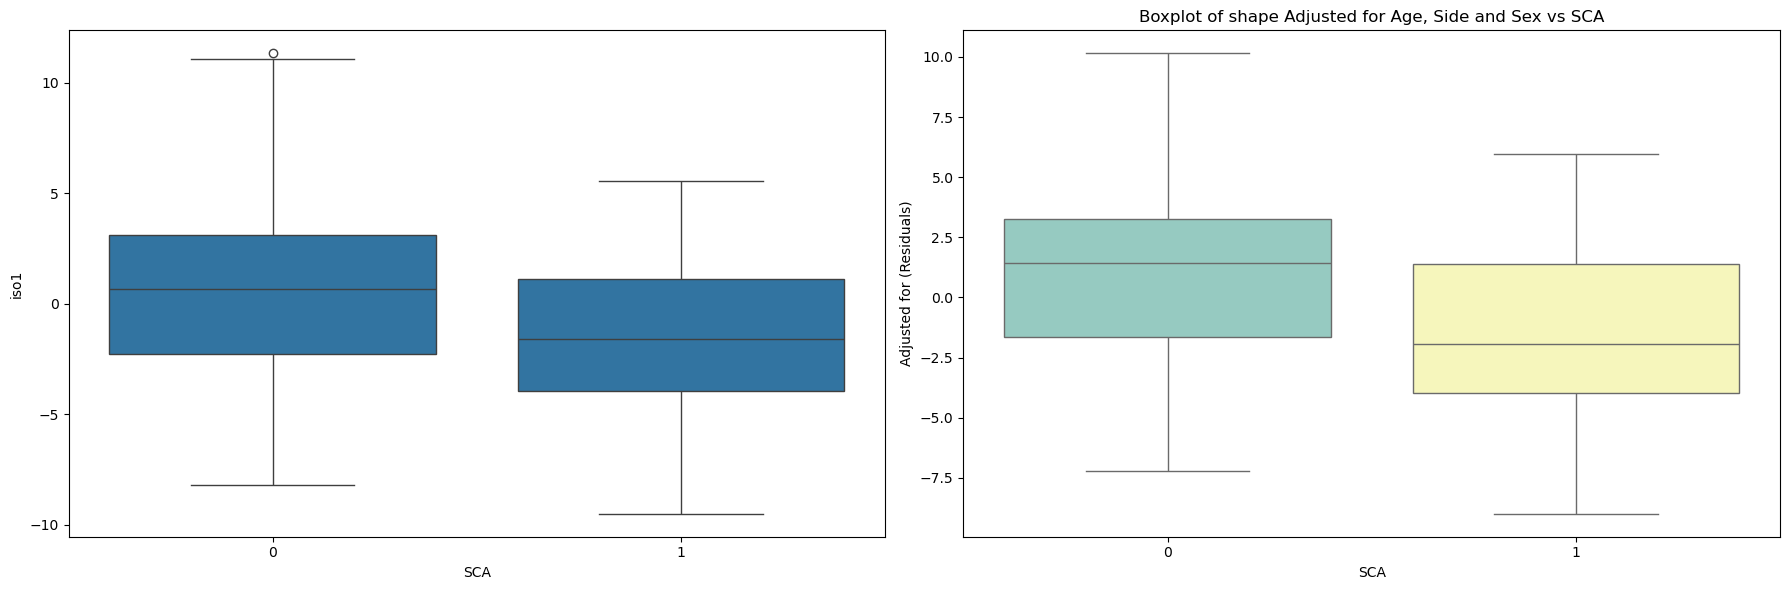

In [36]:
###########  boxplot with and without adjusting for cofactors  ###########
df = combined
curData = 'iso1'
new_name = curData + '_adjusted'

df['side_numeric'] = pd.Categorical(df['side'].map({'L': 0, 'R': 1}), categories=[0, 1])
df_cleaned = df

# Regress curData on cofactors to adjust for these cofactors
cofactors = ['Age', 'side_numeric']
X = sm.add_constant(df_cleaned[cofactors])  # Add constant for intercept
model = sm.OLS(df_cleaned[curData], X).fit()
df_cleaned[new_name] = model.resid  # Residuals represent iso1 adjusted for cofactors

# COMPARE: Boxplot of original and adjusted iso1 vs SCA
fig, axs = plt.subplots(1, 2, figsize=(18, 6))

sns.boxplot(x='SCA', y=curData, data=df, ax=axs[0])
plt.title('Box Plot of ' + curData + ' by SCA Type')
plt.xlabel('SCA Type')
plt.ylabel(curData)

sns.boxplot(x='SCA', y=new_name, data=df_cleaned, palette="Set3", ax=axs[1])
plt.title("Boxplot of shape Adjusted for Age, Side and Sex vs SCA")
plt.xlabel("SCA")
plt.ylabel("Adjusted for (Residuals)")

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

Text(0, 0.5, 'iso1')

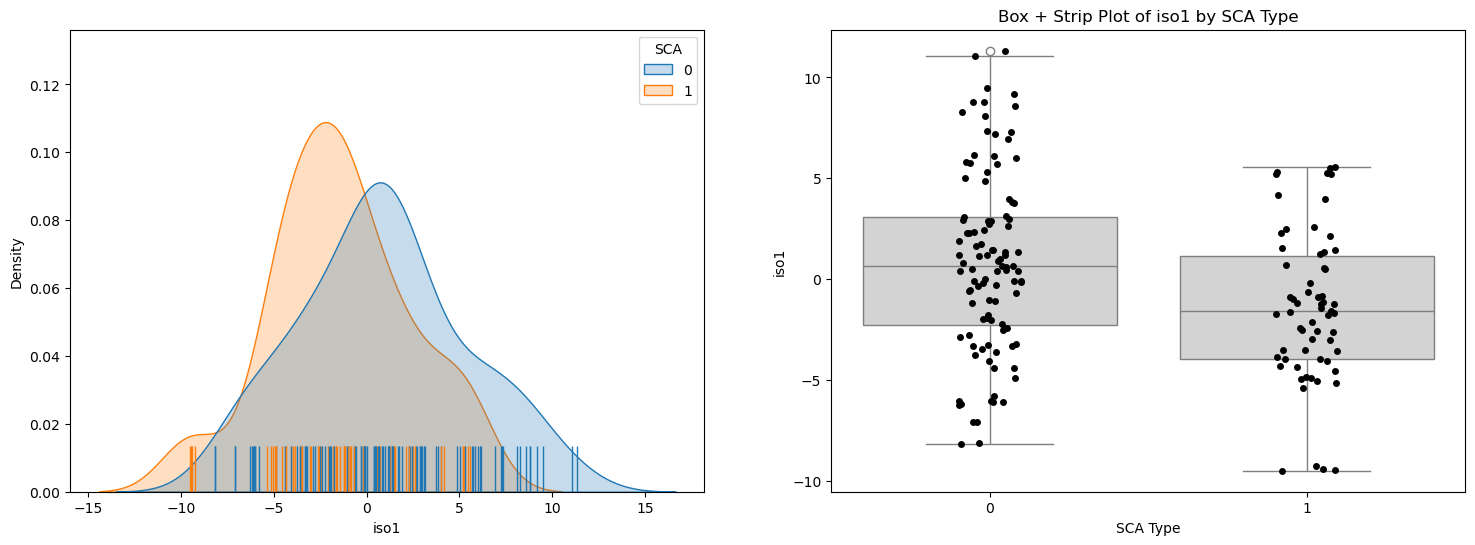

In [38]:
###############  density plot and Box+strip plot  ################

df = combined
curData = 'iso1'

fig, axs = plt.subplots(1, 2, figsize=(18, 6))

sns.kdeplot(data=df, x=curData, hue='SCA', fill=True, common_norm=False, ax=axs[0])
sns.rugplot(data=df, x=curData, hue='SCA', height=0.1, legend=False, ax=axs[0])
plt.title('Density Plot with Rug of ' + curData + ' by SCA Type')
plt.xlabel(curData)
plt.ylabel('Density')

sns.boxplot(x='SCA', y=curData, data=df, color='lightgray', ax=axs[1])
sns.stripplot(x='SCA', y=curData, data=df, color='black', jitter=True)
plt.title('Box + Strip Plot of ' + curData + ' by SCA Type')
plt.xlabel('SCA Type')
plt.ylabel(curData)


Text(0, 0.5, 'Density')

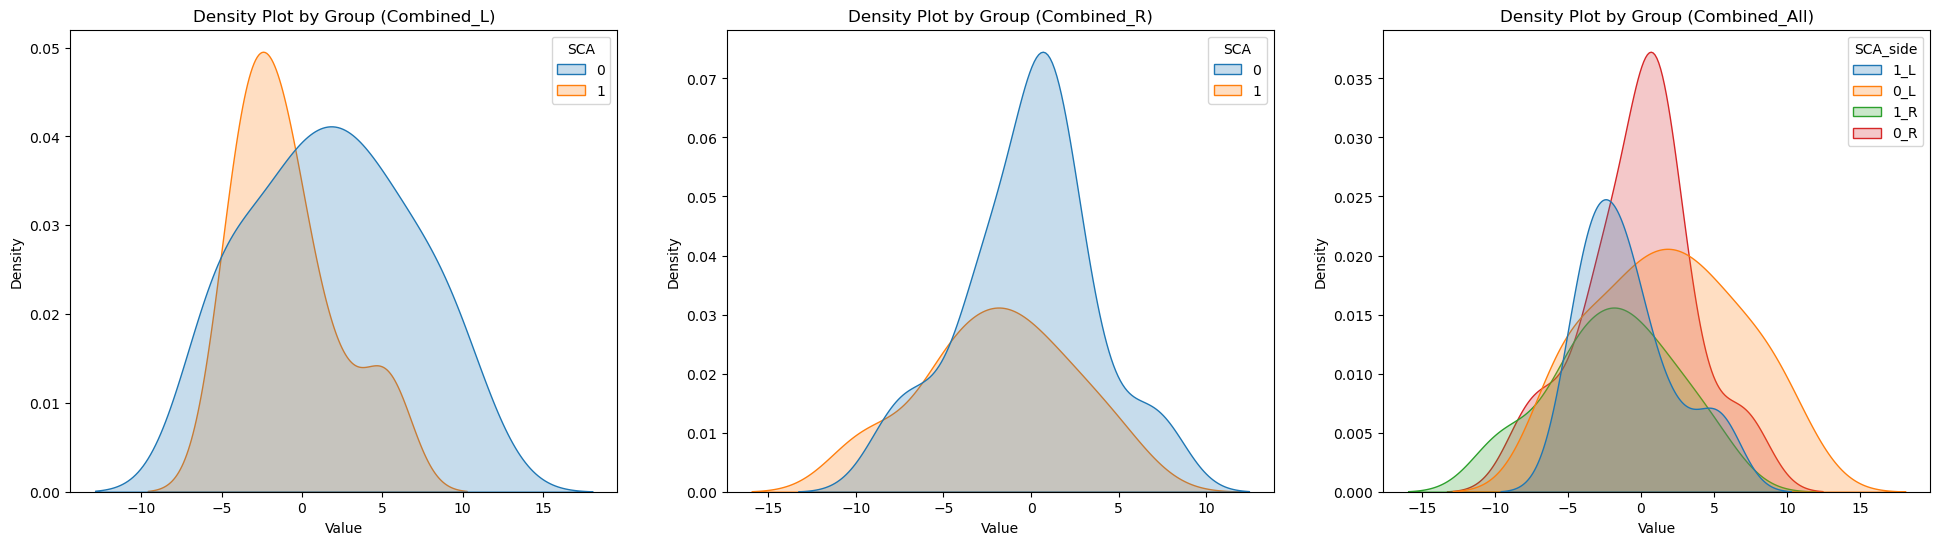

In [42]:
#################  density plot multiple groups, compare hemispheres  ##################

fig, axs = plt.subplots(1, 3, figsize=(24, 6))  # 3 subplots in a row, larger figure size for better spacing
# First plot
sns.kdeplot(data=combined_L, x='iso1', hue='SCA', fill=True, ax=axs[0])
axs[0].set_title('Density Plot by Group (Combined_L)')
axs[0].set_xlabel('Value')
axs[0].set_ylabel('Density')

# Second plot
sns.kdeplot(data=combined_R, x='iso1', hue='SCA', fill=True, ax=axs[1])
axs[1].set_title('Density Plot by Group (Combined_R)')
axs[1].set_xlabel('Value')
axs[1].set_ylabel('Density')

# third plot
sns.kdeplot(data=combined, x='iso1', hue='SCA_side', fill=True, ax=axs[2]) # default colors
axs[2].set_title('Density Plot by Group (Combined_All)')
axs[2].set_xlabel('Value')
axs[2].set_ylabel('Density')

Text(0, 0.5, 'Density')

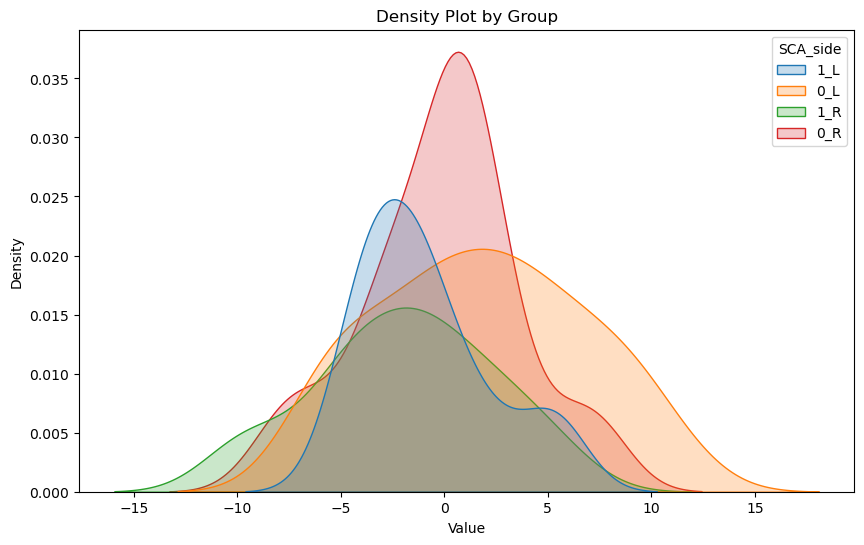

In [46]:
#################  density plot multiple groups  ##################

plt.figure(figsize=(10, 6))
sns.kdeplot(data=combined, x='iso1', hue='SCA_side', fill=True) # default colors

# Customize the plot
plt.title('Density Plot by Group')
plt.xlabel('Value')
plt.ylabel('Density')

#plt.savefig(r'D:\B_projWIP\proj_ataxia\plots_dec_2024\density_combined_ctl_SCA1_time2_inBoth_max_byHemisphere.png')

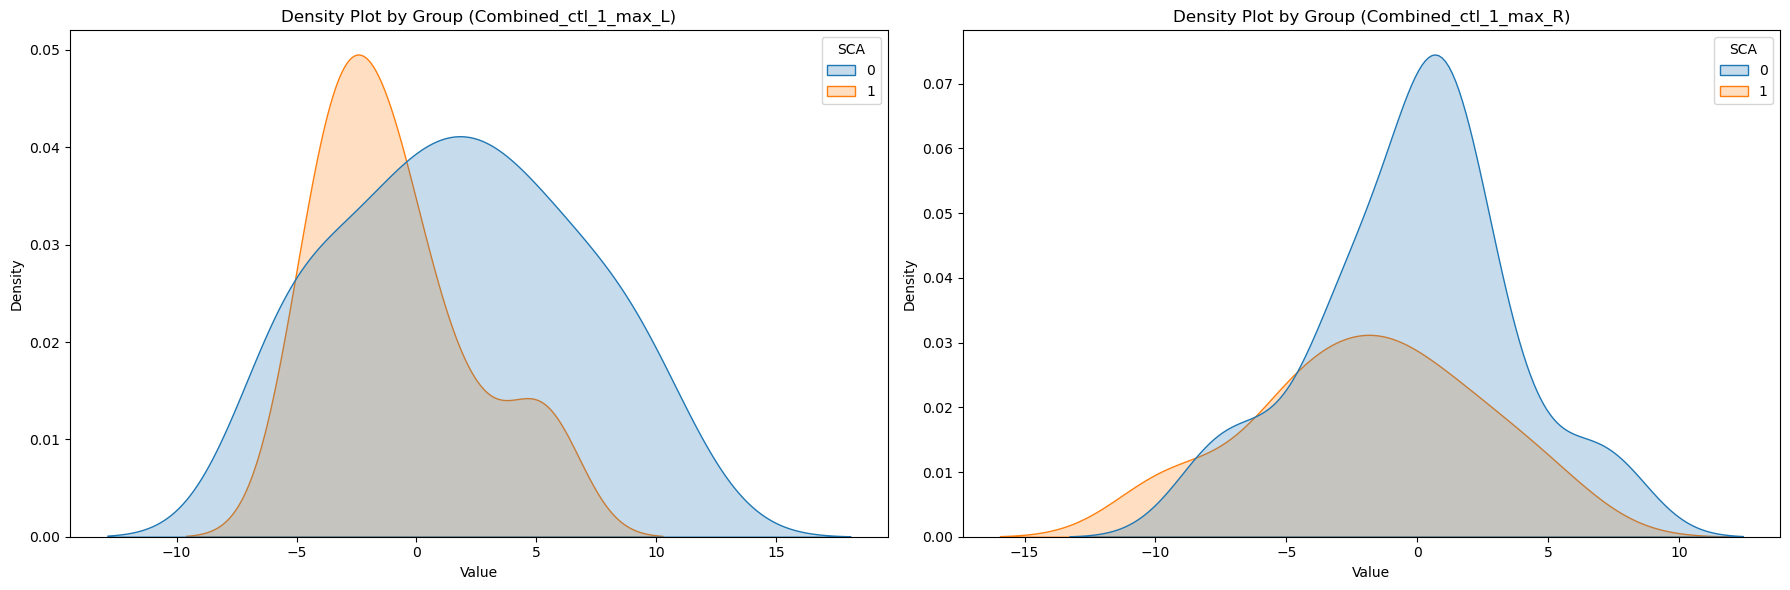

In [50]:
################################  plotting left and right hemisphere  #################################
fig, axs = plt.subplots(1, 2, figsize=(18, 6))

# First plot
sns.kdeplot(data=combined_L, x='iso1', hue='SCA', fill=True, ax=axs[0])
axs[0].set_title('Density Plot by Group (Combined_ctl_1_max_L)')
axs[0].set_xlabel('Value')
axs[0].set_ylabel('Density')

# Second plot
sns.kdeplot(data=combined_R, x='iso1', hue='SCA', fill=True, ax=axs[1])
axs[1].set_title('Density Plot by Group (Combined_ctl_1_max_R)')
axs[1].set_xlabel('Value')
axs[1].set_ylabel('Density')

# Adjust layout for better spacing
plt.tight_layout()
#plt.savefig(r'D:\B_projWIP\proj_ataxia\plots\density_ctl_1_iso1_max_L_R.png')

# Show the plots
plt.show()